
# VGG-16 on ImageNet: Then vs. Now

This notebook trains **VGG-16 from scratch in PyTorch** on ImageNet-1k.

The goal is not to exactly reproduce the full 2014 training run. Instead, we keep the important VGG ideas and show how much easier the *engineering workflow* is today:

- the original VGG-16 architecture
- 224×224 ImageNet images
- training from random initialization
- ImageNet streamed from Hugging Face
- automatic mixed precision (AMP)
- AdamW
- cosine learning-rate scheduling
- label smoothing
- gradient accumulation
- automatic batch-size selection based on GPU memory
- TQDM progress bars with live loss, accuracy, learning rate, and throughput

The original VGG paper used minibatch SGD with momentum, batch size 256, weight decay, dropout, and a manually reduced learning rate. The full training ran for 74 epochs / about 370K iterations.

Here we use a **modern teaching configuration** that can show learning in one Colab session.

> Important: a short run on a subset of ImageNet is a demonstration, not a reproduction of VGG's published ImageNet accuracy.



## Before you run

In Colab, choose:

**Runtime → Change runtime type → GPU**

ImageNet on Hugging Face is gated by the ImageNet terms of access.  
Before running the data-loading cell:

1. Open the Hugging Face `ILSVRC/imagenet-1k` dataset page.
2. Accept the access conditions.
3. Create a Hugging Face access token if needed.
4. The notebook will ask you to log in once.

The data are **streamed**. We do not download the entire ImageNet dataset to Colab.


In [1]:

# Package helper for Colab
def ensure_package_installed(package_name, import_name=None):
    """
    Ensures a Python package is installed and imported.

    Args:
        package_name (str): Name used in pip install (e.g., 'torchinfo').
        import_name (str): Module name used in import (e.g., 'torchinfo', 'sklearn').
                           Defaults to package_name.

    Returns:
        module: The imported module object.
    """
    import importlib
    import subprocess
    import sys

    import_name = import_name or package_name

    try:
        return importlib.import_module(import_name)
    except ImportError:
        print(f"Installing '{package_name}'...")
        subprocess.check_call([sys.executable, "-m", "pip", "install", package_name])
        return importlib.import_module(import_name)


datasets = ensure_package_installed("datasets")
huggingface_hub = ensure_package_installed("huggingface_hub")
tqdm_module = ensure_package_installed("tqdm")


In [2]:

import math
import os
import random
import time
from dataclasses import dataclass, asdict

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
from datasets import load_dataset
from huggingface_hub import notebook_login
from torch.utils.data import DataLoader
from torchvision import transforms
from torchvision.models import vgg16
from tqdm.auto import tqdm

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

if device.type == "cuda":
    props = torch.cuda.get_device_properties(0)
    print("GPU:", props.name)
    print(f"GPU memory: {props.total_memory / 1024**3:.1f} GB")
else:
    print("Warning: this notebook is intended to run with a Colab GPU.")


Device: cuda
GPU: NVIDIA GeForce RTX 3090
GPU memory: 24.0 GB



## Configuration

Three useful modes are provided:

- `"quick"` — very short teaching demo
- `"classroom"` — default; enough work to see the training process clearly
- `"extended"` — substantially more ImageNet exposure

All modes still train **from scratch**.

VGG-16 is memory-hungry because of both its early high-resolution feature maps and its large fully-connected classifier.  
The notebook therefore chooses a physical batch size from the GPU's memory and uses **gradient accumulation** to reach a larger effective batch size.


In [3]:

@dataclass
class Config:
    run_mode: str = "classroom"

    # ImageNet / model
    dataset_name: str = "ILSVRC/imagenet-1k"
    num_classes: int = 1000
    image_size: int = 224

    # Modern optimization
    learning_rate: float = 1e-4 # 3e-4
    weight_decay: float = 5e-4
    label_smoothing: float = 0.1
    target_effective_batch_size: int = 128

    # Streaming
    shuffle_buffer: int = 10_000

    # Set below by configure_run()
    epochs: int = 3
    train_samples_per_epoch: int = 50_000
    val_samples: int = 10_000
    batch_size: int = 16
    grad_accum_steps: int = 8


def get_memory_gb():
    if not torch.cuda.is_available():
        return 0.0
    return torch.cuda.get_device_properties(0).total_memory / 1024**3

def choose_batch_size():
    """
    Conservative VGG-16 batch size selection for common Colab GPUs.
    AMP is enabled later, but VGG still consumes substantial activation memory.
    """
    if not torch.cuda.is_available():
        return 4

    memory_gb = get_memory_gb()

    if memory_gb >= 38:
        return 64      # e.g. A100 40 GB
    elif memory_gb >= 22:
        return 64 # 32      # e.g. L4 24 GB
    elif memory_gb >= 14:
        return 16      # e.g. T4 16 GB
    else:
        return 8

def configure_run(cfg):
    if cfg.run_mode == "quick":
        cfg.epochs = 2
        cfg.train_samples_per_epoch = 20_000
        cfg.val_samples = 5_000
    elif cfg.run_mode == "classroom":
        cfg.epochs = 3
        cfg.train_samples_per_epoch = 50_000
        cfg.val_samples = 10_000
    elif cfg.run_mode == "extended":
        cfg.epochs = 50
        cfg.train_samples_per_epoch = 150_000
        cfg.val_samples = 20_000
    else:
        raise ValueError("run_mode must be 'quick', 'classroom', or 'extended'.")

    cfg.batch_size = choose_batch_size()
    cfg.grad_accum_steps = max(
        1,
        math.ceil(cfg.target_effective_batch_size / cfg.batch_size)
    )
    return cfg

# cfg = configure_run(Config(run_mode="classroom"))
cfg = configure_run(Config(run_mode="extended"))

print("Memory:", get_memory_gb(), "GB")
print("Configuration")
for key, value in asdict(cfg).items():
    print(f"{key:28s}: {value}")

print(
    "\nApproximate effective batch size:",
    cfg.batch_size * cfg.grad_accum_steps
)


Memory: 23.99951171875 GB
Configuration
run_mode                    : extended
dataset_name                : ILSVRC/imagenet-1k
num_classes                 : 1000
image_size                  : 224
learning_rate               : 0.0001
weight_decay                : 0.0005
label_smoothing             : 0.1
target_effective_batch_size : 128
shuffle_buffer              : 10000
epochs                      : 50
train_samples_per_epoch     : 150000
val_samples                 : 20000
batch_size                  : 64
grad_accum_steps            : 2

Approximate effective batch size: 128



## Hugging Face login

Run this once per new Colab session if Hugging Face is not already authenticated.

If access fails, first make sure you have accepted the ImageNet access conditions on Hugging Face.


In [4]:

notebook_login()



## Local ImageNet subset cache

Streaming is excellent for getting started quickly, but it is less attractive when we train for several epochs: later epochs can still depend on network I/O.

So this notebook uses a hybrid strategy:

1. **First run:** stream only the requested subset from Hugging Face.
2. Save those images locally in ImageFolder format.
3. **All training epochs:** read the images from local disk.

The cache location is selected automatically:

- **Google Colab:** `/content/imagenet_vgg_cache`
- **Local Jupyter:** `./data/imagenet_vgg_cache`

You can override it by setting the environment variable `VGG_IMAGENET_CACHE`.

This is deliberately a *teaching-subset cache*, not a download of all ImageNet.


In [5]:

from pathlib import Path
import json
import shutil
import sys


def running_in_colab():
    return "google.colab" in sys.modules

def get_content_dir():
    override = os.environ.get("VGG_IMAGENET_DATA")
    if override:
        return Path(override).expanduser().resolve() / '..'

    if running_in_colab():
        return Path("/content")
    else:
        return Path("./data")

def get_data_dir_root():
    content_dir = get_content_dir()
    return (content_dir /"imagenet_vgg_data").resolve()


def get_cache_root():
    content_dir = get_content_dir()
    cache_dir = content_dir / "imagenet_vgg_cache"
    return cache_dir.resolve()


CACHE_ROOT = get_cache_root()
CACHE_ROOT.mkdir(parents=True, exist_ok=True)



print("Running in Colab:", running_in_colab())
print("Data root directory:", get_data_dir_root())
print("Local ImageNet cache:", CACHE_ROOT)


Running in Colab: False
Data root directory: C:\Users\Assaf\program\CourseUtils\Notebooks\data\imagenet_vgg_data
Local ImageNet cache: C:\Users\Assaf\program\CourseUtils\Notebooks\data\imagenet_vgg_cache



### Materialize a streamed subset

Each class is stored in a zero-padded directory such as:

```text
imagenet_vgg_cache/
    train_50000_seed42/
        0000/
        0001/
        ...
        0999/
    validation_10000/
        0000/
        ...
```

The zero padding is important because `torchvision.datasets.ImageFolder` sorts class-directory names. With `0000 ... 0999`, the folder index remains identical to the original ImageNet label.

A small manifest marks a cache as complete. If an interrupted download leaves a partial cache, the function safely rebuilds it.


In [6]:

from torchvision.datasets import ImageFolder


def cache_manifest_path(split_dir):
    return split_dir / "_cache_manifest.json"


def cache_is_complete(split_dir, expected_samples, seed, split_name):
    manifest_path = cache_manifest_path(split_dir)

    if not split_dir.exists() or not manifest_path.exists():
        return False

    try:
        with open(manifest_path, "r", encoding="utf-8") as f:
            manifest = json.load(f)

        return (
            manifest.get("dataset_name") == cfg.dataset_name
            and manifest.get("split") == split_name
            and manifest.get("samples") == expected_samples
            and manifest.get("seed") == seed
        )
    except Exception:
        return False


def materialize_stream_to_imagefolder(
    stream,
    split_dir,
    expected_samples,
    split_name,
    seed,
):
    """Save a Hugging Face iterable image dataset as a local ImageFolder dataset."""
    if cache_is_complete(split_dir, expected_samples, seed, split_name):
        print(f"Using existing local cache: {split_dir}")
        return

    if split_dir.exists():
        print(f"Removing incomplete cache: {split_dir}")
        shutil.rmtree(split_dir)

    split_dir.mkdir(parents=True, exist_ok=True)

    print(f"Caching {expected_samples:,} {split_name} images locally...")

    progress = tqdm(
        stream,
        total=expected_samples,
        desc=f"Cache {split_name}",
    )

    saved = 0

    for index, example in enumerate(progress):
        if index >= expected_samples:
            break

        image = example["image"].convert("RGB")
        label = int(example["label"])

        class_dir = split_dir / f"{label:04d}"
        class_dir.mkdir(parents=True, exist_ok=True)

        image_path = class_dir / f"{index:08d}.jpg"
        image.save(image_path, format="JPEG", quality=92, optimize=False)
        saved += 1

    if saved != expected_samples:
        raise RuntimeError(
            f"Expected {expected_samples:,} images, but cached {saved:,}."
        )

    manifest = {
        "dataset_name": cfg.dataset_name,
        "split": split_name,
        "samples": saved,
        "seed": seed,
    }

    with open(cache_manifest_path(split_dir), "w", encoding="utf-8") as f:
        json.dump(manifest, f, indent=2)

    print(f"Finished caching {saved:,} images in {split_dir}")



## Image preprocessing

The VGG paper trained on RGB ImageNet images and used 224×224 crops.

For this modern teaching run we use a standard contemporary ImageNet augmentation pipeline:

**Training**
- random resized crop
- random horizontal flip
- ImageNet normalization

**Validation**
- resize
- center crop
- ImageNet normalization


In [7]:

IMAGENET_MEAN = (0.485, 0.456, 0.406)
IMAGENET_STD = (0.229, 0.224, 0.225)

train_transform = transforms.Compose([
    transforms.RandomResizedCrop(cfg.image_size, scale=(0.6, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

val_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(cfg.image_size),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

def make_transform(transform):
    def transform_example(example):
        image = example["image"].convert("RGB")
        return {
            "pixel_values": transform(image),
            "label": int(example["label"]),
        }
    return transform_example



## Build the local teaching cache

We still use Hugging Face streaming for the **first pass**, so there is no need to download all of ImageNet.

For training, the stream is shuffled before taking the requested sample budget. For validation, we take a deterministic sample.

Once these images are cached, subsequent notebook runs reuse them automatically when the configuration matches.


In [8]:
import os

# Hugging Face defaults to a fairly short timeout.
# ImageNet parquet shards are large enough that slower connections may hit it.
os.environ["HF_HUB_DOWNLOAD_TIMEOUT"] = "120"
os.environ["HF_HUB_ETAG_TIMEOUT"] = "120" # "30"

In [9]:
print("Opening ImageNet streams for cache preparation...")

raw_train_stream = load_dataset(
    cfg.dataset_name,
    split="train",
    streaming=True,
)

train_cache_stream = raw_train_stream.take(
    cfg.train_samples_per_epoch
)

raw_val_stream = load_dataset(
    cfg.dataset_name,
    split="validation",
    streaming=True,
)

val_cache_stream = raw_val_stream.take(cfg.val_samples)

TRAIN_CACHE_DIR = CACHE_ROOT / f"train_{cfg.train_samples_per_epoch}_seed{SEED}"
VAL_CACHE_DIR = CACHE_ROOT / f"validation_{cfg.val_samples}"

materialize_stream_to_imagefolder(
    train_cache_stream,
    TRAIN_CACHE_DIR,
    cfg.train_samples_per_epoch,
    split_name="train",
    seed=SEED,
)

materialize_stream_to_imagefolder(
    val_cache_stream,
    VAL_CACHE_DIR,
    cfg.val_samples,
    split_name="validation",
    seed=SEED,
)

print("Local cache is ready.")


Opening ImageNet streams for cache preparation...


Resolving data files:   0%|          | 0/294 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/28 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/294 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/28 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/294 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/28 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/294 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/28 [00:00<?, ?it/s]

Using existing local cache: C:\Users\Assaf\program\CourseUtils\Notebooks\data\imagenet_vgg_cache\train_150000_seed42
Using existing local cache: C:\Users\Assaf\program\CourseUtils\Notebooks\data\imagenet_vgg_cache\validation_20000
Local cache is ready.


In [10]:
# Training now happens entirely from local files.

train_dataset = ImageFolder(
    TRAIN_CACHE_DIR,
    transform=train_transform,
)

val_dataset = ImageFolder(
    VAL_CACHE_DIR,
    transform=val_transform,
)

print("Number of cached training images:", len(train_dataset))
print("Number of cached validation images:", len(val_dataset))
print("Number of training classes represented:", len(train_dataset.classes))

NUM_WORKERS = min(4, os.cpu_count() or 1)

train_loader = DataLoader(
    train_dataset,
    batch_size=cfg.batch_size,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available(),
    persistent_workers=NUM_WORKERS > 0,
)

val_loader = DataLoader(
    val_dataset,
    batch_size=cfg.batch_size,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available(),
    persistent_workers=NUM_WORKERS > 0,
)

train_batches = len(train_loader)
val_batches = len(val_loader)

print("DataLoader workers:", NUM_WORKERS)
print("Training batches per epoch:", train_batches)
print("Validation batches:", val_batches)


Number of cached training images: 150000
Number of cached validation images: 20000
Number of training classes represented: 1000
DataLoader workers: 4
Training batches per epoch: 2344
Validation batches: 313



## Inspect a streamed batch

This is worth doing before launching a long training loop.

Expected tensor shape:

$$ \text{batch} \times 3 \times 224 \times 224 $$


In [11]:

images, labels = next(iter(train_loader))

print("Images:", images.shape, images.dtype)
print("Labels:", labels.shape, labels.dtype)
print("Label range in this batch:", int(labels.min()), "to", int(labels.max()))


Images: torch.Size([64, 3, 224, 224]) torch.float32
Labels: torch.Size([64]) torch.int64
Label range in this batch: 20 to 992



## Create VGG-16 from scratch

`weights=None` is important.

We are **not** fine-tuning a pretrained network.  
This is the familiar VGG-16 architecture starting from random weights.


In [12]:

model = vgg16(weights=None, num_classes=cfg.num_classes)

# Channels-last memory format can improve convolution performance on modern NVIDIA GPUs.
model = model.to(device, memory_format=torch.channels_last)

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"Total parameters:     {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")
print()
print(model)


Total parameters:     138,357,544
Trainable parameters: 138,357,544

VGG(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU(inplace=True)
    (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU(inplace=True)
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU(inplace=True)
    (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (15): ReLU(inplace=Tru


## Modern training recipe

The original VGG training recipe used SGD + momentum.

For this demonstration we intentionally use conveniences that are common today:

- **AdamW**
- **label smoothing**
- **cosine learning-rate decay**
- **automatic mixed precision**
- **gradient accumulation**

This changes the optimization recipe, but not the central architectural lesson of VGG.


In [13]:

criterion = nn.CrossEntropyLoss(
    label_smoothing=cfg.label_smoothing
)

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=cfg.learning_rate,
    weight_decay=cfg.weight_decay,
)

optimizer_steps_per_epoch = math.ceil(
    train_batches / cfg.grad_accum_steps
)
total_optimizer_steps = cfg.epochs * optimizer_steps_per_epoch

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=max(1, total_optimizer_steps),
)

# Modern AMP API where available
amp_enabled = device.type == "cuda"
scaler = torch.amp.GradScaler("cuda", enabled=amp_enabled)

print("Optimizer steps per epoch:", optimizer_steps_per_epoch)
print("Total optimizer steps:", total_optimizer_steps)
print("AMP enabled:", amp_enabled)


Optimizer steps per epoch: 1172
Total optimizer steps: 58600
AMP enabled: True



## Accuracy helper

For ImageNet we normally report both:

- **Top-1 accuracy** — the correct class is the model's first choice
- **Top-5 accuracy** — the correct class appears among the model's five highest-scoring choices


In [14]:

@torch.no_grad()
def topk_correct(logits, targets, topk=(1, 5)):
    max_k = max(topk)

    _, predictions = logits.topk(max_k, dim=1)
    predictions = predictions.t()

    correct = predictions.eq(targets.view(1, -1))

    result = []
    for k in topk:
        result.append(correct[:k].reshape(-1).float().sum().item())

    return result



## Training and validation loops with TQDM

The progress bar shows:

- current smoothed loss
- running Top-1 accuracy
- running Top-5 accuracy
- learning rate
- approximate images/second

The denominator of the loss is adjusted for gradient accumulation, so several small physical batches behave like one larger optimization batch.


In [15]:

def train_one_epoch(model, loader, optimizer, scheduler, scaler, epoch, cfg):
    model.train()

    running_loss = 0.0
    total_examples = 0
    total_top1 = 0.0
    total_top5 = 0.0

    optimizer.zero_grad(set_to_none=True)

    start_time = time.perf_counter()

    progress = tqdm(
        loader,
        total=train_batches,
        desc=f"Train {epoch + 1}/{cfg.epochs}",
        leave=True,
    )

    for batch_idx, (images, targets) in enumerate(progress):
        images = images.to(
            device,
            non_blocking=True,
            memory_format=torch.channels_last,
        )
        targets = targets.to(device, non_blocking=True)

        batch_size_actual = targets.size(0)

        with torch.autocast(
            device_type=device.type,
            dtype=torch.float16,
            enabled=amp_enabled,
        ):
            logits = model(images)
            raw_loss = criterion(logits, targets)
            loss = raw_loss / cfg.grad_accum_steps

        scaler.scale(loss).backward()

        should_step = (
            (batch_idx + 1) % cfg.grad_accum_steps == 0
            or (batch_idx + 1) == train_batches
        )

        if should_step:
            scaler.step(optimizer)
            scaler.update()
            optimizer.zero_grad(set_to_none=True)
            scheduler.step()

        top1, top5 = topk_correct(logits.detach(), targets)

        running_loss += raw_loss.item() * batch_size_actual
        total_examples += batch_size_actual
        total_top1 += top1
        total_top5 += top5

        elapsed = time.perf_counter() - start_time
        images_per_second = total_examples / max(elapsed, 1e-9)

        progress.set_postfix(
            loss=f"{running_loss / total_examples:.3f}",
            top1=f"{100 * total_top1 / total_examples:.1f}%",
            top5=f"{100 * total_top5 / total_examples:.1f}%",
            lr=f"{optimizer.param_groups[0]['lr']:.2e}",
            ips=f"{images_per_second:.0f}",
        )

    return {
        "loss": running_loss / total_examples,
        "top1": 100 * total_top1 / total_examples,
        "top5": 100 * total_top5 / total_examples,
        "images_per_second": total_examples / (time.perf_counter() - start_time),
    }


@torch.no_grad()
def validate(model, loader, epoch, cfg):
    model.eval()

    running_loss = 0.0
    total_examples = 0
    total_top1 = 0.0
    total_top5 = 0.0

    progress = tqdm(
        loader,
        total=val_batches,
        desc=f"Valid {epoch + 1}/{cfg.epochs}",
        leave=True,
    )

    for images, targets in progress:
        images = images.to(
            device,
            non_blocking=True,
            memory_format=torch.channels_last,
        )
        targets = targets.to(device, non_blocking=True)

        with torch.autocast(
            device_type=device.type,
            dtype=torch.float16,
            enabled=amp_enabled,
        ):
            logits = model(images)
            loss = criterion(logits, targets)

        batch_size_actual = targets.size(0)
        top1, top5 = topk_correct(logits, targets)

        running_loss += loss.item() * batch_size_actual
        total_examples += batch_size_actual
        total_top1 += top1
        total_top5 += top5

        progress.set_postfix(
            loss=f"{running_loss / total_examples:.3f}",
            top1=f"{100 * total_top1 / total_examples:.1f}%",
            top5=f"{100 * total_top5 / total_examples:.1f}%",
        )

    return {
        "loss": running_loss / total_examples,
        "top1": 100 * total_top1 / total_examples,
        "top5": 100 * total_top5 / total_examples,
    }



## Train

A checkpoint is saved whenever validation Top-1 accuracy improves.

If you only want to demonstrate the mechanics in class, `"quick"` mode is enough.  
For a more visible learning curve, use `"classroom"` or `"extended"`.


In [ ]:
def train_one_epoch_debug(model, loader, optimizer, scheduler, scaler, epoch, cfg):
    model.train()

    running_loss = 0.0
    total_examples = 0
    total_top1 = 0.0
    total_top5 = 0.0
    optimizer.zero_grad(set_to_none=True)

    start_time = time.perf_counter()

    progress = tqdm(loader, total=train_batches, desc=f"Train {epoch + 1}/{cfg.epochs}", leave=True)
    DEBUG_EVERY = 100
    for batch_idx, (images, targets) in enumerate(progress):
        images = images.to(device, non_blocking=True, memory_format=torch.channels_last)
        targets = targets.to(device, non_blocking=True)
        batch_size_actual = targets.size(0)

        with torch.autocast(device_type=device.type, dtype=torch.float16, enabled=amp_enabled):
            logits = model(images)
            raw_loss = criterion(logits, targets)
            loss = raw_loss / cfg.grad_accum_steps
        scaler.scale(loss).backward()

        should_step = (batch_idx + 1) % cfg.grad_accum_steps == 0 or (batch_idx + 1) == train_batches
        grad_norm = None
        if should_step:
            # Unscale once per step for a stable grad-norm reading
            scaler.unscale_(optimizer)
            total_sq = 0.0
            for p in model.parameters():
                if p.grad is not None:
                    total_sq += float(p.grad.detach().pow(2).sum().item())
            grad_norm = (total_sq ** 0.5) if total_sq > 0 else 0.0
            scaler.step(optimizer)
            scaler.update()
            optimizer.zero_grad(set_to_none=True)
            scheduler.step()

        # Batch-level metrics
        top1, top5 = topk_correct(logits.detach(), targets)
        running_loss += raw_loss.item() * batch_size_actual
        total_examples += batch_size_actual
        total_top1 += top1
        total_top5 += top5

        # Occasional detailed diagnostics
        if batch_idx < 5 or (batch_idx % DEBUG_EVERY == 0):
            with torch.no_grad():
                img_min = float(images.min().item())
                img_max = float(images.max().item())
                img_mean = float(images.mean().item())
                img_std = float(images.std().item())
                lg_mean = float(logits.detach().mean().item())
                lg_std = float(logits.detach().std().item())
                probs = torch.softmax(logits.detach().float(), dim=1)
                conf_mean = float(probs.max(dim=1).values.mean().item())
                lbl_min = int(targets.min().item())
                lbl_max = int(targets.max().item())
                b_top1 = float(top1 / batch_size_actual)
                print(
                    f"b{(batch_idx+1):<5}: loss={raw_loss.item():.3f} lr={optimizer.param_groups[0]['lr']:.2e} ",
                    f"img[min={img_min:.3f},max={img_max:.3f},mu={img_mean:.3f},sd={img_std:.3f}] ",
                    f"logits[mu={lg_mean:.3f},sd={lg_std:.3f}] conf={conf_mean:.3f} ",
                    f"labels[{lbl_min},{lbl_max}] top1={100*b_top1:.1f}% ",
                    (f"| grad_norm={grad_norm:.2f}" if grad_norm is not None else ""),
                )

        elapsed = time.perf_counter() - start_time
        images_per_second = total_examples / max(elapsed, 1e-9)
        progress.set_postfix(
            loss=f"{running_loss / total_examples:.3f}",
            top1=f"{100 * total_top1 / total_examples:.1f}%",
            top5=f"{100 * total_top5 / total_examples:.1f}%",
            lr=f"{optimizer.param_groups[0]['lr']:.2e}",
            ips=f"{images_per_second:.0f}",
        )

    return {
        "loss": running_loss / total_examples,
        "top1": 100 * total_top1 / total_examples,
        "top5": 100 * total_top5 / total_examples,
        "images_per_second": total_examples / (time.perf_counter() - start_time),
    }

In [17]:
# Diagnostic and debugging utilities for training

def debug_batch_data(train_loader):
    images, labels = next(iter(train_loader))
    print(f"Debug batch - images shape: {images.shape}, dtype: {images.dtype}")
    print(f"Debug batch - labels shape: {labels.shape}, min: {labels.min()}, max: {labels.max()}")



# Print LR and label smoothing
print(f"Current learning rate: {optimizer.param_groups[0]['lr']}")
print(f"Label smoothing: {cfg.label_smoothing}")
print(f"AMP enabled: {amp_enabled}")



# Quick overfit check on small batch

def quick_overfit_check():
    small_loader = DataLoader(train_dataset, batch_size=8, shuffle=True)
    for i, (images, targets) in enumerate(small_loader):
        images = images.to(device)
        targets = targets.to(device)
        logits = model(images)
        loss = criterion(logits, targets)
        print(f"Batch {i+1} quick overfit loss: {loss.item()}")
        if i >= 5:
            break


Current learning rate: 0.0001
Label smoothing: 0.1
AMP enabled: True


In [18]:
best_network_file_name = get_data_dir_root() / "vgg16_imagenet_best.pt"

history = {
    "train_loss": [],
    "train_top1": [],
    "train_top5": [],
    "val_loss": [],
    "val_top1": [],
    "val_top5": [],
}

best_val_top1 = -1.0

for epoch in range(cfg.epochs):
    train_metrics = train_one_epoch_debug( #train_one_epoch(
        model,
        train_loader,
        optimizer,
        scheduler,
        scaler,
        epoch,
        cfg,
    )

    val_metrics = validate(
        model,
        val_loader,
        epoch,
        cfg,
    )

    history["train_loss"].append(train_metrics["loss"])
    history["train_top1"].append(train_metrics["top1"])
    history["train_top5"].append(train_metrics["top5"])

    history["val_loss"].append(val_metrics["loss"])
    history["val_top1"].append(val_metrics["top1"])
    history["val_top5"].append(val_metrics["top5"])

    print(
        f"\nEpoch {epoch + 1}: "
        f"train loss={train_metrics['loss']:.4f}, "
        f"train top-1={train_metrics['top1']:.2f}%, "
        f"val top-1={val_metrics['top1']:.2f}%, "
        f"val top-5={val_metrics['top5']:.2f}%"
    )

    if val_metrics["top1"] > best_val_top1:
        best_val_top1 = val_metrics["top1"]

        torch.save(
            {
                "epoch": epoch + 1,
                "model_state_dict": model.state_dict(),
                "optimizer_state_dict": optimizer.state_dict(),
                "best_val_top1": best_val_top1,
                "config": asdict(cfg),
            },
            "best_network_file_name",
        )

        print(
            f"Saved new best checkpoint "
            f"(validation Top-1 = {best_val_top1:.2f}%)."
        )


Train 1/50:   0%|          | 0/2344 [00:00<?, ?it/s]

b1    : loss=6.915 lr=1.00e-04  img[min=-2.118,max=2.640,mu=-0.002,sd=1.246]  logits[mu=-0.002,sd=0.083] conf=0.001  labels[5,980] top1=0.0%  
b2    : loss=6.920 lr=1.00e-04  img[min=-2.118,max=2.640,mu=-0.080,sd=1.169]  logits[mu=-0.001,sd=0.077] conf=0.001  labels[12,988] top1=0.0%  | grad_norm=1.31
b3    : loss=6.909 lr=1.00e-04  img[min=-2.118,max=2.640,mu=-0.069,sd=1.191]  logits[mu=-0.025,sd=0.106] conf=0.001  labels[3,991] top1=0.0%  
b4    : loss=6.896 lr=1.00e-04  img[min=-2.118,max=2.640,mu=0.059,sd=1.209]  logits[mu=-0.024,sd=0.106] conf=0.001  labels[17,998] top1=0.0%  | grad_norm=1.41
b5    : loss=6.923 lr=1.00e-04  img[min=-2.118,max=2.640,mu=0.101,sd=1.165]  logits[mu=-0.065,sd=0.158] conf=0.002  labels[20,982] top1=0.0%  
b101  : loss=6.909 lr=1.00e-04  img[min=-2.118,max=2.640,mu=0.164,sd=1.217]  logits[mu=-0.016,sd=0.011] conf=0.001  labels[21,987] top1=0.0%  
b201  : loss=6.907 lr=1.00e-04  img[min=-2.118,max=2.640,mu=0.017,sd=1.176]  logits[mu=-0.010,sd=0.007] conf=

Valid 1/50:   0%|          | 0/313 [00:14<?, ?it/s]


Epoch 1: train loss=6.8751, train top-1=0.13%, val top-1=0.30%, val top-5=1.40%
Saved new best checkpoint (validation Top-1 = 0.30%).


Train 2/50:   0%|          | 0/2344 [00:00<?, ?it/s]

...


Epoch 49: train loss=2.1111, train top-1=76.54%, val top-1=37.65%, val top-5=63.11%


Train 50/50:   0%|          | 0/2344 [00:00<?, ?it/s]

b1    : loss=1.997 lr=9.87e-08  img[min=-2.118,max=2.640,mu=-0.006,sd=1.255]  logits[mu=-28.312,sd=6.371] conf=0.588  labels[27,957] top1=79.7%  
b2    : loss=1.901 lr=9.85e-08  img[min=-2.118,max=2.640,mu=0.006,sd=1.219]  logits[mu=-27.047,sd=5.391] conf=0.628  labels[3,995] top1=85.9%  | grad_norm=7.42
b3    : loss=1.844 lr=9.85e-08  img[min=-2.118,max=2.640,mu=0.036,sd=1.187]  logits[mu=-28.734,sd=6.496] conf=0.609  labels[11,987] top1=84.4%  
b4    : loss=2.075 lr=9.83e-08  img[min=-2.118,max=2.640,mu=-0.009,sd=1.273]  logits[mu=-28.250,sd=5.820] conf=0.577  labels[48,981] top1=79.7%  | grad_norm=7.68
b5    : loss=1.923 lr=9.83e-08  img[min=-2.118,max=2.640,mu=0.001,sd=1.196]  logits[mu=-27.891,sd=6.562] conf=0.628  labels[16,973] top1=90.6%  
b101  : loss=2.029 lr=9.04e-08  img[min=-2.118,max=2.640,mu=0.021,sd=1.214]  logits[mu=-28.984,sd=6.434] conf=0.588  labels[7,978] top1=82.8%  
b201  : loss=2.216 lr=8.25e-08  img[min=-2.118,max=2.640,mu=0.059,sd=1.181]  logits[mu=-29.094,sd=

Valid 50/50:   0%|          | 0/313 [00:00<?, ?it/s]


Epoch 50: train loss=2.1104, train top-1=76.53%, val top-1=37.62%, val top-5=63.12%



## Plot the learning curves


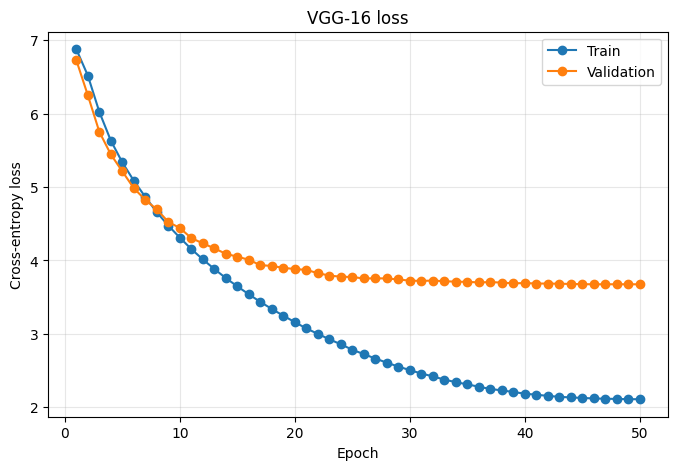

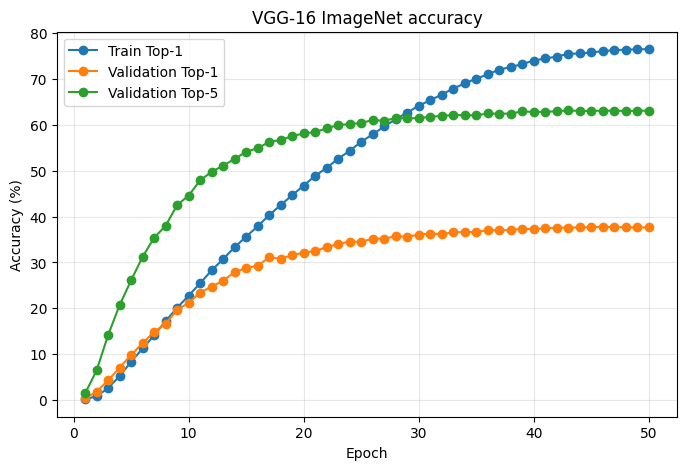

In [19]:

epochs_axis = np.arange(1, len(history["train_loss"]) + 1)

plt.figure(figsize=(8, 5))
plt.plot(epochs_axis, history["train_loss"], marker="o", label="Train")
plt.plot(epochs_axis, history["val_loss"], marker="o", label="Validation")
plt.xlabel("Epoch")
plt.ylabel("Cross-entropy loss")
plt.title("VGG-16 loss")
plt.grid(alpha=0.3)
plt.legend()
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(epochs_axis, history["train_top1"], marker="o", label="Train Top-1")
plt.plot(epochs_axis, history["val_top1"], marker="o", label="Validation Top-1")
plt.plot(epochs_axis, history["val_top5"], marker="o", label="Validation Top-5")
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.title("VGG-16 ImageNet accuracy")
plt.grid(alpha=0.3)
plt.legend()
plt.show()



## What did modern tooling buy us?

The interesting comparison is not only model accuracy.

The 2014 recipe required substantial manual engineering around:

- multi-GPU training
- data ingestion
- optimization scheduling
- experiment monitoring
- checkpointing
- GPU numerical precision

Today, much of this is a few lines of PyTorch:

- `torchvision.models.vgg16(...)`
- Hugging Face streaming + a reusable local teaching cache
- `torch.autocast(...)`
- `GradScaler`
- AdamW
- built-in schedulers
- TQDM

However, the **compute itself has not disappeared**.

Full VGG-16 training on all 1.28 million ImageNet training images for dozens of epochs is still a serious computation.  
The dramatic change is that reproducing the *workflow* is now accessible from a notebook, and a reduced experiment can be run interactively in class.



## Optional experiment: use the original-style optimizer

To make the optimization closer to the VGG paper, replace AdamW with:

```python
optimizer = torch.optim.SGD(
    model.parameters(),
    lr=0.01,
    momentum=0.9,
    weight_decay=5e-4,
)
```

The original paper used:

- batch size: 256
- momentum: 0.9
- weight decay: $5 \times 10^{-4}$
- dropout: 0.5 in the first two fully connected layers
- initial learning rate: $10^{-2}$
- learning-rate reductions by a factor of 10
- about 74 epochs total

The `torchvision` VGG-16 architecture already includes the characteristic dropout in its classifier.

For a short Colab run, AdamW usually makes the demonstration more forgiving.



## Optional challenge for students

Try changing **one** modern convenience at a time:

1. AdamW → SGD with momentum
2. AMP on → AMP off
3. effective batch size 128 → 32
4. label smoothing 0.1 → 0
5. classroom mode → quick mode

Before running each experiment, predict:

- Will training be faster or slower?
- Will GPU memory usage change?
- Will convergence become smoother or noisier?
- Is the change computational, statistical, or both?



## Cache management

The local cache is intentionally reusable.

To force a rebuild, delete the corresponding cache directory, or change the sample budget in `Config`.

Different teaching budgets automatically create separate directories, for example:

```text
train_20000_seed42/
train_50000_seed42/
train_150000_seed42/
```

On ordinary Jupyter, the default cache remains in `./data/imagenet_vgg_cache` across sessions.

On standard Colab storage, `/content/...` disappears when the runtime is destroyed. If you want persistence across Colab runtimes, mount Google Drive and set the environment variable before the cache-location cell, for example:

```python
os.environ["VGG_IMAGENET_CACHE"] = "/content/drive/MyDrive/datasets/imagenet_vgg_cache"
```

For actual training speed, local `/content` storage will usually be preferable to reading every training batch directly from Drive. A useful workflow is to keep a persistent copy on Drive only if repeated Colab sessions justify it, then copy the subset to `/content` at the start of a session.
